---
title: null
---

<a id="anwendungen-bildverarbeitung"></a>

## Anwendungen in der Bildverarbeitung

Die Hadamard-Multiplikation spielt eine wichtige Rolle in der Bildverarbeitung, insbesondere bei der Anwendung von Filtern auf Bilder.

Typische Anwendungen umfassen:

- Faltung (Convolution) von Bildern mit einem Filter
- Pixelweise Filterung und Bildrauschen-Reduktion
- Kantenerkennung

<a id="sobel-filter"></a>

### Beispiel: Kantenerkennung mit einem Sobel-Filter

Ein häufig verwendeter Filter in der Bildverarbeitung ist der **Sobel-Filter** zur Kantenerkennung.

Der horizontale bzw. vertikale Sobel-Filter wird durch folgende $3\times3$-Matrizen dargestellt:

$$
S_x=
\begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix}
\qquad
S_y=
\begin{bmatrix}
-1 & -2 & -1\\
0 & 0 & 0\\
1 & 2 & 1
\end{bmatrix}.
$$

Dieser Filter wird pixelweise auf das Bild durch Hadamard-Multiplikation angewendet, um horizontale bzw. vertikale Kanten zu erkennen.

Er berechnet Gradienten in einem Bild, um Kanten zu identifizieren. Diese Gradienten repräsentieren die Richtungsänderungen der Intensitäten (Helligkeit) im Bild.

<a id="matrix-graustufenbild"></a>

### Matrix als Graustufenbild

Eine Matrix mit Werten von 0 bis 255 kann als Graustufenbild interpretiert werden, wobei jedes Element die Intensität eines Pixels darstellt.

Der Wert 0 entspricht Schwarz, 255 entspricht Weiß, und Zwischenwerte stellen verschiedene Grautöne dar.

Hier ist ein Beispiel:

$$
\begin{bmatrix}
0 & 51 & 102 & 153 & 204\\
51 & 102 & 153 & 204 & 255\\
102 & 153 & 204 & 255 & 204\\
153 & 204 & 255 & 204 & 153\\
204 & 255 & 204 & 153 & 102
\end{bmatrix}
$$

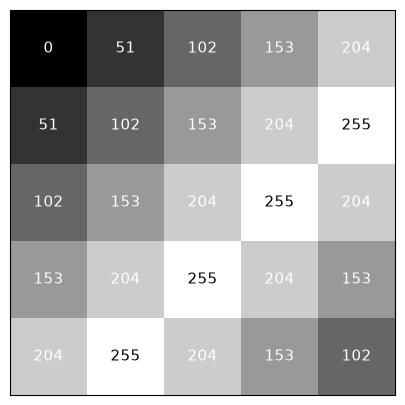

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([
    [0,   51, 102, 153, 204],
    [51, 102, 153, 204, 255],
    [102, 153, 204, 255, 204],
    [153, 204, 255, 204, 153],
    [204, 255, 204, 153, 102]
])

fig, ax = plt.subplots(figsize=(5, 5))

ax.imshow(A, cmap="gray", vmin=0, vmax=255)

# Pixelwerte eintragen
for i in range(A.shape[0]):
    for j in range(A.shape[1]):
        farbe = "black" if A[i, j] >= 220 else "white"
        ax.text(
            j, i,
            str(A[i, j]),
            ha="center",
            va="center",
            color=farbe,
            fontsize=11
        )

ax.set_xticks([])
ax.set_yticks([])

plt.show()

<a id="bildverarbeitung-filterung"></a>

### Bildverarbeitung: Filterung durch Hadamard-Multiplikation

Bei der Bildverarbeitung wird das Bild als eine Matrix von Pixelwerten (meist Graustufen) dargestellt.

Die Hadamard-Multiplikation mit einem Filter ermöglicht die direkte Anwendung von Filtermasken auf jedes Pixel:

- Weichzeichnen: Durch Multiplikation mit einem Gaußschen Weichzeichner-Filter.
- Bildschärfung: Mithilfe eines Schärfefilters, um Details hervorzuheben.
- Rauschreduktion: Durch Filtern von unerwünschten Bildinformationen.

<a id="anwendung-filter-hadamard"></a>

### Anwendung des Filters durch Hadamard-Multiplikation

Die **Hadamard-Multiplikation** (elementweise Multiplikation) wird verwendet, um den Sobel-Filter auf das Bild anzuwenden.

Dabei wird die $3\times3$-Sobel-Matrix pixelweise mit einem $3\times3$-Ausschnitt des Bildes multipliziert.

Dies geschieht sowohl für den horizontalen Filter $S_x$ als auch für den vertikalen Filter $S_y$.

<a id="sobel-7x7"></a>

### Anwendung des Sobel-Filters auf eine $7\times7$-Matrix

Die Anwendung eines **Sobel-Filters** auf eine Matrix erfolgt durch das „Schieben“ des $3\times3$-Filters über das Bild.

Betrachten wir eine $7\times7$-Matrix $A$ als Bild:

$$
A=
\begin{bmatrix}
10 & 20 & 30 & 40 & 50 & 60 & 70\\
15 & 25 & 35 & 45 & 55 & 65 & 75\\
20 & 30 & 40 & 50 & 60 & 70 & 80\\
25 & 35 & 45 & 55 & 65 & 75 & 85\\
30 & 40 & 50 & 60 & 70 & 80 & 90\\
35 & 45 & 55 & 65 & 75 & 85 & 95\\
40 & 50 & 60 & 70 & 80 & 90 & 100
\end{bmatrix}
$$

Der **Sobel-Filter** $S_x$ wird von der $3\times3$ Matrix dargestelllt

$$
S_x=
\begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix}.
$$

### Anwendung des Sobel-Filters auf eine $7\times7$-Matrix

Der Sobel-Filter $S_x$ wird auf lokale $3\times3$-Bereiche des Bildes angewendet.

Betrachten wir den oberen linken $3\times3$-Bereich von $A$:

$$
A=
\begin{bmatrix}
\mathbf{10} & \mathbf{20} & \mathbf{30} & 40 & 50 & 60 & 70\\
\mathbf{15} & \mathbf{25} & \mathbf{35} & 45 & 55 & 65 & 75\\
\mathbf{20} & \mathbf{30} & \mathbf{40} & 50 & 60 & 70 & 80\\
25 & 35 & 45 & 55 & 65 & 75 & 85\\
30 & 40 & 50 & 60 & 70 & 80 & 90\\
35 & 45 & 55 & 65 & 75 & 85 & 95\\
40 & 50 & 60 & 70 & 80 & 90 & 100
\end{bmatrix}
$$

Hier ist die hervorgehobene $3\times3$-Region:

$$
\text{Region}
=
\begin{bmatrix}
10 & 20 & 30\\
15 & 25 & 35\\
20 & 30 & 40
\end{bmatrix}.
$$

Diese Region wird durch Hadamard-Multiplikation mit dem Sobel-Filter $S_x$ multipliziert.

### Ersetzen des zentralen Elements der $3\times3$-Region

Die Hadamard-Multiplikation des Sobel-Filters $S_x$ mit der $3\times3$-Region ergibt:

$$
S_x\circ\text{Region}
=
\begin{bmatrix}
-1 & 0 & 1\\
-2 & 0 & 2\\
-1 & 0 & 1
\end{bmatrix}
\circ
\begin{bmatrix}
10 & 20 & 30\\
15 & 25 & 35\\
20 & 30 & 40
\end{bmatrix}
$$

$$
=
\begin{bmatrix}
-10 & 0 & 30\\
-30 & 0 & 70\\
-20 & 0 & 40
\end{bmatrix}.
$$

Der neue Wert für das zentrale Pixel $A(2,2)$ wird berechnet als die Summe der Elemente der resultierenden Matrix:

$$
A(2,2)_{\text{neu}}
=
\sum_{i=1}^{3}
\sum_{j=1}^{3}
S_x(i,j)\cdot A(i,j)
$$

$$
=
-10+0+30+(-30)+0+70+(-20)+0+40
=
80.
$$



Dieser Wert $80$ wird als neuer Pixelwert in das Ergebnisbild eingefügt:

$$
A_{\text{neu}}
=
\begin{bmatrix}
10 & 20 & 30 & 40 & 50 & 60 & 70\\
15 & \mathbf{80} & 35 & 45 & 55 & 65 & 75\\
20 & 30 & 40 & 50 & 60 & 70 & 80\\
25 & 35 & 45 & 55 & 65 & 75 & 85\\
30 & 40 & 50 & 60 & 70 & 80 & 90\\
35 & 45 & 55 & 65 & 75 & 85 & 95\\
40 & 50 & 60 & 70 & 80 & 90 & 100
\end{bmatrix}.
$$

Dieser Prozess wird auf jede $3\times3$-Region des Bildes wiederholt, indem der Filter über das gesamte Bild geschoben wird.

<a id="randpixel"></a>

### Behandlung der Randpixel mit der $7\times7$-Matrix

Beim Anwenden des Sobel-Filters auf eine Matrix können Randpixel nicht direkt gefiltert werden, da ihnen in einigen Richtungen notwendige Nachbarn fehlen, die für die Anwendung des $3\times3$-Filters erforderlich sind.

Daher werden verschiedene Methoden zur Behandlung der Randpixel eingesetzt.

**Gegebene $7\times7$-Matrix $A$:**

$$
A=
\begin{bmatrix}
10 & 20 & 30 & 40 & 50 & 60 & 70\\
15 & 25 & 35 & 45 & 55 & 65 & 75\\
20 & 30 & 40 & 50 & 60 & 70 & 80\\
25 & 35 & 45 & 55 & 65 & 75 & 85\\
30 & 40 & 50 & 60 & 70 & 80 & 90\\
35 & 45 & 55 & 65 & 75 & 85 & 95\\
40 & 50 & 60 & 70 & 80 & 90 & 100
\end{bmatrix}.
$$

### Übersicht der Methoden zur Behandlung von Randpixeln

- **Replicate (Wiederholung):** Wiederholt die Randwerte.
- **Symmetric (Spiegelung):** Spiegelt die Werte an den Rändern.
- **Zero-Padding:** Füllt Bereiche außerhalb des Bildes mit Nullen.
- **Circular (Zirkulär):** Behandelt das Bild, als ob es zirkulär wäre.

**Wichtig:** Die Wahl der Randbehandlungsmethode kann die Ergebnisse der Filterung beeinflussen. Es ist daher entscheidend, die Methode zu wählen, die am besten zum Anwendungsfall passt.

### Randbehandlung – Replicate (Wiederholung)

Bei der **Replicate**-Methode werden die Randwerte durch Wiederholung der äußersten Pixel des Bildes erweitert.

**Erweiterte Matrix ($9\times9$):**

$$
\begin{bmatrix}
\boxed{10} & \boxed{10} & \boxed{20} & \boxed{30} & \boxed{40} & \boxed{50} & \boxed{60} & \boxed{70} & \boxed{70}\\
\boxed{10} & 10 & 20 & 30 & 40 & 50 & 60 & 70 & \boxed{70}\\
\boxed{15} & 15 & 25 & 35 & 45 & 55 & 65 & 75 & \boxed{75}\\
\boxed{20} & 20 & 30 & 40 & 50 & 60 & 70 & 80 & \boxed{80}\\
\boxed{25} & 25 & 35 & 45 & 55 & 65 & 75 & 85 & \boxed{85}\\
\boxed{30} & 30 & 40 & 50 & 60 & 70 & 80 & 90 & \boxed{90}\\
\boxed{35} & 35 & 45 & 55 & 65 & 75 & 85 & 95 & \boxed{95}\\
\boxed{40} & 40 & 50 & 60 & 70 & 80 & 90 & 100 & \boxed{100}\\
\boxed{40} & \boxed{40} & \boxed{50} & \boxed{60} & \boxed{70} & \boxed{80} & \boxed{90} & \boxed{100} & \boxed{100}
\end{bmatrix}
$$

**Hinweis:** Die eingerahmten Werte sind die replizierten Randwerte.

### Randbehandlung – Symmetric (Spiegelung)

Bei der **Symmetric**-Methode werden die Randwerte durch Spiegelung der Pixel am Rand erzeugt.

**Erweiterte Matrix ($9\times9$):**

$$
\begin{bmatrix}
\boxed{25} & \boxed{15} & \boxed{25} & \boxed{35} & \boxed{45} & \boxed{55} & \boxed{65} & \boxed{75} & \boxed{65}\\
\boxed{20} & 10 & 20 & 30 & 40 & 50 & 60 & 70 & \boxed{60}\\
\boxed{25} & 15 & 25 & 35 & 45 & 55 & 65 & 75 & \boxed{65}\\
\boxed{30} & 20 & 30 & 40 & 50 & 60 & 70 & 80 & \boxed{70}\\
\boxed{35} & 25 & 35 & 45 & 55 & 65 & 75 & 85 & \boxed{75}\\
\boxed{40} & 30 & 40 & 50 & 60 & 70 & 80 & 90 & \boxed{80}\\
\boxed{45} & 35 & 45 & 55 & 65 & 75 & 85 & 95 & \boxed{85}\\
\boxed{50} & 40 & 50 & 60 & 70 & 80 & 90 & 100 & \boxed{90}\\
\boxed{45} & \boxed{35} & \boxed{45} & \boxed{55} & \boxed{65} & \boxed{75} & \boxed{85} & \boxed{95} & \boxed{85}
\end{bmatrix}
$$

**Hinweis:** Die eingerahmten Werte sind die gespiegelten Randwerte.

### Randbehandlung – Zero-Padding

Bei der **Zero-Padding**-Methode werden die Randwerte mit Nullen aufgefüllt.

**Erweiterte Matrix ($9\times9$):**

$$
\begin{bmatrix}
\boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0}\\
\boxed{0} & 10 & 20 & 30 & 40 & 50 & 60 & 70 & \boxed{0}\\
\boxed{0} & 15 & 25 & 35 & 45 & 55 & 65 & 75 & \boxed{0}\\
\boxed{0} & 20 & 30 & 40 & 50 & 60 & 70 & 80 & \boxed{0}\\
\boxed{0} & 25 & 35 & 45 & 55 & 65 & 75 & 85 & \boxed{0}\\
\boxed{0} & 30 & 40 & 50 & 60 & 70 & 80 & 90 & \boxed{0}\\
\boxed{0} & 35 & 45 & 55 & 65 & 75 & 85 & 95 & \boxed{0}\\
\boxed{0} & 40 & 50 & 60 & 70 & 80 & 90 & 100 & \boxed{0}\\
\boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0} & \boxed{0}
\end{bmatrix}
$$

**Hinweis:** Die eingerahmten Werte sind die mit Nullen aufgefüllten Randwerte.

### Randbehandlung – Circular (Zirkulär)

Bei der **Circular**-Methode werden die Randwerte durch Umwickeln des Bildes erzeugt.

**Erweiterte Matrix ($9\times9$):**

$$
\begin{bmatrix}
\boxed{100} & \boxed{40} & \boxed{50} & \boxed{60} & \boxed{70} & \boxed{80} & \boxed{90} & \boxed{100} & \boxed{40}\\
\boxed{70} & 10 & 20 & 30 & 40 & 50 & 60 & 70 & \boxed{10}\\
\boxed{75} & 15 & 25 & 35 & 45 & 55 & 65 & 75 & \boxed{15}\\
\boxed{80} & 20 & 30 & 40 & 50 & 60 & 70 & 80 & \boxed{20}\\
\boxed{85} & 25 & 35 & 45 & 55 & 65 & 75 & 85 & \boxed{25}\\
\boxed{90} & 30 & 40 & 50 & 60 & 70 & 80 & 90 & \boxed{30}\\
\boxed{95} & 35 & 45 & 55 & 65 & 75 & 85 & 95 & \boxed{35}\\
\boxed{100} & 40 & 50 & 60 & 70 & 80 & 90 & 100 & \boxed{40}\\
\boxed{70} & \boxed{10} & \boxed{20} & \boxed{30} & \boxed{40} & \boxed{50} & \boxed{60} & \boxed{70} & \boxed{10}
\end{bmatrix}
$$

**Hinweis:** Die eingerahmten Werte sind die zirkulär erweiterten Randwerte.

<a id="sobel-32x32"></a>

### Kantenerkennung mit dem Sobel-Filter

Wir betrachten eine Blockmatrix, die aus 4 Blöcken gebildet wird. Die Blöcke haben konstante Werte, wie hier gezeigt:

$$
A=
\begin{bmatrix}
A_{11} & A_{12}\\
A_{21} & A_{22}
\end{bmatrix},
$$

wobei

$$
A_{11}
=
\begin{bmatrix}
10 & 10 & \cdots & 10\\
10 & 10 & \cdots & 10\\
\vdots & \vdots & \ddots & \vdots\\
10 & 10 & \cdots & 10
\end{bmatrix},
$$

$$
A_{12}
=
\begin{bmatrix}
50 & 50 & \cdots & 50\\
50 & 50 & \cdots & 50\\
\vdots & \vdots & \ddots & \vdots\\
50 & 50 & \cdots & 50
\end{bmatrix},
$$

$$
A_{21}
=
\begin{bmatrix}
50 & 50 & \cdots & 50\\
50 & 50 & \cdots & 50\\
\vdots & \vdots & \ddots & \vdots\\
50 & 50 & \cdots & 50
\end{bmatrix}
$$

und

$$
A_{22}
=
\begin{bmatrix}
90 & 90 & \cdots & 90\\
90 & 90 & \cdots & 90\\
\vdots & \vdots & \ddots & \vdots\\
90 & 90 & \cdots & 90
\end{bmatrix}.
$$

### Kantenerkennung auf einer $32\times32$-Matrix

```{figure} Figures/Kantenerkennung.png
:width: 70%
:align: center
:alt: Kantenerkennung auf einer 32x32-Matrix

Das Bild zeigt die Kantenerkennung auf einem $32\times32$ Bild.
```

### MATLAB implementierung des Sobel-Filters

In den folgenden Abschnitten wird ein MATLAB-Code vorgestellt, der den Sobel-Filter auf ein synthetisches $32\times32$-Graustufenbild anwendet, das sowohl vertikale als auch horizontale Kanten enthält.

**Wichtige Schritte:**

- Erstellung eines $32\times32$-Bildes mit intensitätsbasierten Kanten.
- Anwendung von Sobel-Filtern zur Erkennung von vertikalen und horizontalen Kanten.
- Kombination beider Filterergebnisse zur Darstellung der gesamten Kantenstruktur.



**MATLAB Code zur Anwendung des Sobel-Filters auf ein $32\times32$ Bild**

```matlab
% Sobel-Filter auf einem 32x32 Graustufenbild mit 
% vertikalen und horizontalen Kanten

% Erstellen eines synthetischen 32x32 Bildes mit sowohl 
% vertikalen als auch horizontalen Kanten
% Oben links ist dunkel (10), unten rechts ist hell (90), 
% und wir erstellen Kanten in beiden Achsen

image32x32 = [ones(16, 16) * 10, ones(16, 16) * 50; 
              ones(16, 16) * 50, ones(16, 16) * 90]; 

% Anzeige des Originalbildes
figure;
subplot(2,2,1);
imshow(image32x32, []);
title('Original 32x32 Bild');

% Definition der Sobel-Filter für die Erkennung von vertikalen und 
% horizontalen Kanten

sobelX = [-1 0 1; -2 0 2; -1 0 1];  % Sobel-Kern für vert. Kanten
sobelY = [-1 -2 -1; 0 0 0; 1 2 1];  % Sobel-Kern für horiz. Kanten

% Anwenden des Sobel-Filters für vertikale Kanten (S_x)
verticalEdges = imfilter(double(image32x32), sobelX, 'replicate');

% Anwenden des Sobel-Filters für horizontale Kanten (S_y)
horizontalEdges = imfilter(double(image32x32),sobelY,'replicate');

% Anzeige des Ergebnisses der horizontalen Kantenerkennung
subplot(2,2,3);
imshow(horizontalEdges, []);
title('Horizontale Kanten erkannt');

% Kombinieren beider Kanten
edgesCombined = sqrt(verticalEdges.^2 + horizontalEdges.^2);
subplot(2,2,4);
imshow(edgesCombined, []);
title('Kombinierte Kanten (Vertikal + Horizontal)');
```


### Kantenerkennung auf einem $450\times337$ Bild (Motor)

```{figure} Figures/engine_filter.png
:width: 80%
:align: center
:alt: Kantenerkennung auf einem Motorbild
```

**Bildquelle:** [Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Valve_original_(1).PNG), Bild lizenziert unter [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).

<a id="kombination-sobel-filter"></a>

### Kombination der Sobel-Filter in $x$- und $y$-Richtung

Nachdem der Sobel-Filter sowohl in der $x$- als auch in der $y$-Richtung auf das Bild angewendet wurde, wird der kombinierte Effekt berechnet.

Dies geschieht, indem die Ergebnisse der beiden Filter wie folgt zusammengefasst werden:

$$
G=\sqrt{S_x^2+S_y^2}.
$$

Hierbei stehen $S_x$ und $S_y$ für die gefilterten Werte der Sobel-Filter in der $x$- und $y$-Richtung.

Der kombinierte Gradientenwert $G$ repräsentiert die Stärke der Kanten im Bild und wird für jeden Pixel berechnet.

**Skalierung:** Die resultierenden Pixelwerte können skaliert werden, um sie in ein Graustufenbild umzuwandeln. Höhere Gradientenwerte erscheinen heller (weiß), während niedrigere Werte dunkler (schwarz) dargestellt werden.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 32x32-Graustufenbild
# --------------------------------------------------
image32x32 = np.block([
    [
        np.ones((16, 16)) * 10,
        np.ones((16, 16)) * 50
    ],
    [
        np.ones((16, 16)) * 50,
        np.ones((16, 16)) * 90
    ]
])

# --------------------------------------------------
# Sobel-Filter
# --------------------------------------------------
sobelX = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

sobelY = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

# --------------------------------------------------
# Replicate-Randbehandlung
# --------------------------------------------------
padded = np.pad(
    image32x32,
    pad_width=1,
    mode="edge"
)

verticalEdges = np.zeros_like(image32x32)
horizontalEdges = np.zeros_like(image32x32)

# --------------------------------------------------
# Sobel-Filter anwenden
# --------------------------------------------------
for i in range(image32x32.shape[0]):
    for j in range(image32x32.shape[1]):

        region = padded[i:i+3, j:j+3]

        verticalEdges[i, j] = np.sum(region * sobelX)
        horizontalEdges[i, j] = np.sum(region * sobelY)

# Kombination der beiden Richtungen
edgesCombined = np.sqrt(
    verticalEdges**2
    +
    horizontalEdges**2
)

# --------------------------------------------------
# Darstellungen
# --------------------------------------------------

plt.figure(figsize=(6, 6))
plt.imshow(image32x32, cmap="gray")
plt.title("Original 32x32 Bild")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(verticalEdges, cmap="gray")
plt.title("Vertikale Kanten erkannt")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(horizontalEdges, cmap="gray")
plt.title("Horizontale Kanten erkannt")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 6))
plt.imshow(edgesCombined, cmap="gray")
plt.title("Kombinierte Kanten")
plt.axis("off")
plt.show()